## BBC Articles Category Classificatin

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from wordcloud import WordCloud
import string
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


### Loading Data

Data contains BBC news articles + category

In [3]:
df = pd.read_csv("../Data/bbc-text.csv")
df.head()

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


### Exploratory Data Analysis (EDA)

In [4]:
number_of_articles_in_each_category = df["category"].value_counts()

number_of_articles_in_each_category


category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

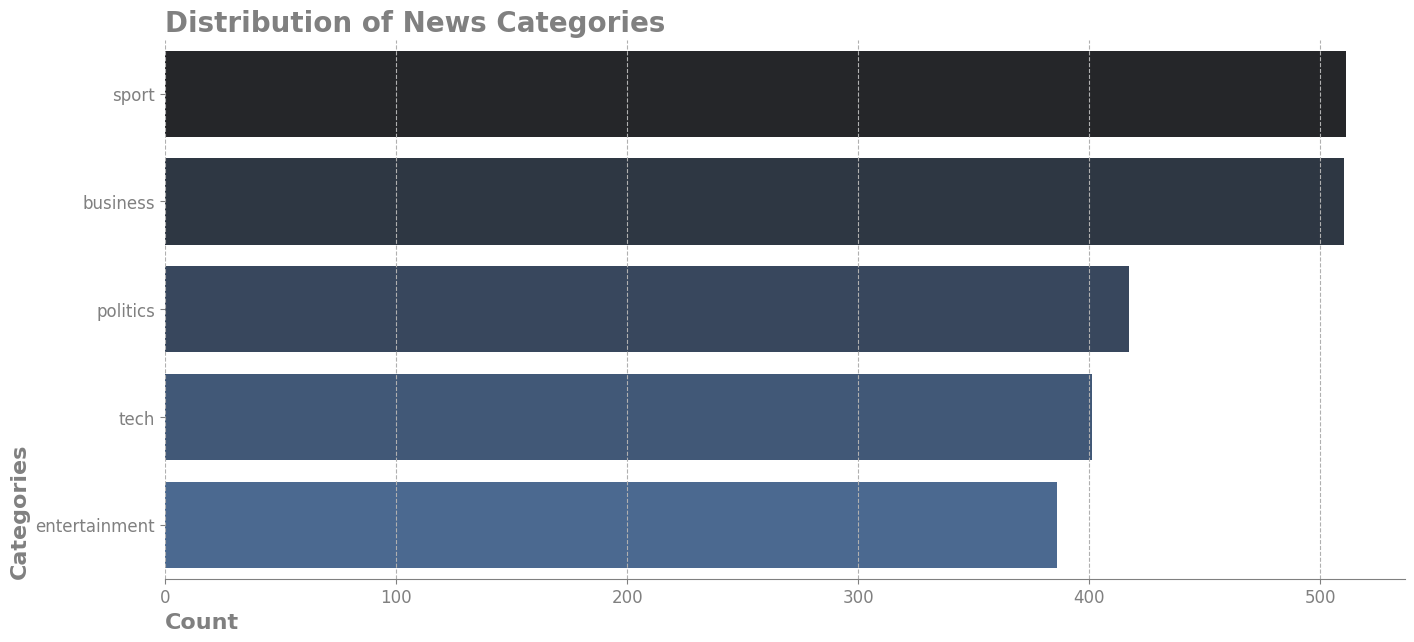

In [5]:
fig ,ax = plt.subplots(figsize = (16,7))
sns.barplot(x = number_of_articles_in_each_category.values,
            y = number_of_articles_in_each_category.index,
            hue = number_of_articles_in_each_category.index,
            palette="dark:#3F679C",
            ax = ax)
ax.spines[["right","left","top"]].set_visible(False)
ax.spines[["bottom"]].set_color("gray")
ax.tick_params(axis="x",
               colors= "gray",
               labelsize= "large")
ax.tick_params(axis="y",
               colors= "gray",
               labelsize= "large")

ax.set_title("Distribution of News Categories",
             loc="left",
             weight = "bold",
             color="gray",
             fontsize=20)

ax.set_xlabel("Count",
              loc="left",
              weight="bold",
              fontsize = 16,
              color="gray"
              )
ax.set_ylabel("Categories",
              weight="bold",
              loc="bottom",
              fontsize = 16,
              color="gray")
ax.grid(axis="x", linestyle = "dashed")


### Preprocessing

In [6]:
# nltk.download('punkt')
# nltk.download('stopwords')
# nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(pos_tag):
    if pos_tag.startswith("J"):
        return wordnet.ADJ
    elif pos_tag.startswith("N"):
        return wordnet.NOUN
    elif pos_tag.startswith("V"):
        return wordnet.VERB
    elif pos_tag.startswith("R"):
        return wordnet.ADV
    else:
        return wordnet.NOUN


def preprocess_text(text):
    text = text.lower()

    text = text.translate(str.maketrans("","",string.punctuation))

    tokens = word_tokenize(text)

    cleaned_tokens = [token for token in tokens if token not in stop_words]
    
    pos_tags = nltk.pos_tag(cleaned_tokens)
    lemmatized_tokens = [lemmatizer.lemmatize(token,get_wordnet_pos(pos)) for token ,pos in pos_tags]
    processed_articles = " ".join(lemmatized_tokens)


    return processed_articles

df["preprocessed_text"] = df["text"].apply(preprocess_text)


In [7]:
df.head()

,category,text,preprocessed_text
0,tech,tv future in the hands of viewers with home th...,tv future hand viewer home theatre system plas...
1,business,worldcom boss left books alone former worldc...,worldcom bos leave book alone former worldcom ...
2,sport,tigers wary of farrell gamble leicester say ...,tiger wary farrell gamble leicester say rush m...
3,sport,yeading face newcastle in fa cup premiership s...,yeading face newcastle fa cup premiership side...
4,entertainment,ocean s twelve raids box office ocean s twelve...,ocean twelve raid box office ocean twelve crim...


### Wordcloud for each Category

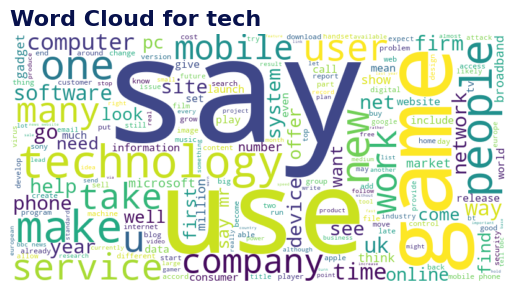

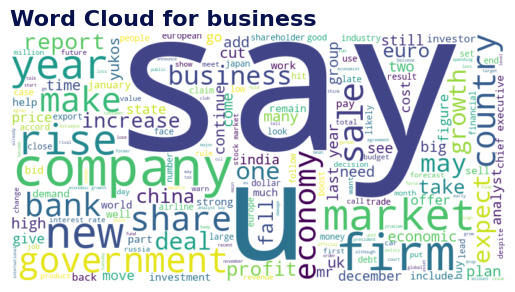

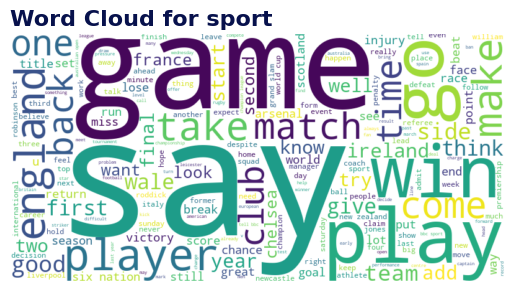

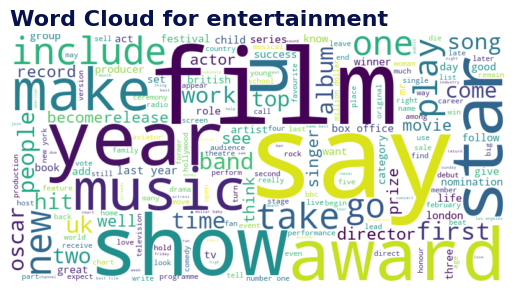

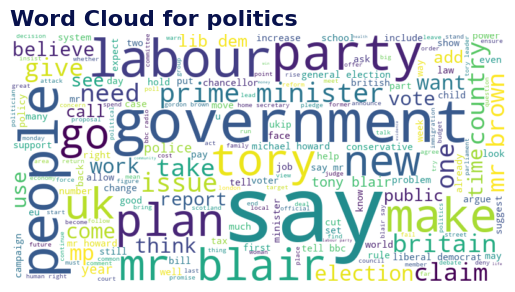

In [8]:
for category in df["category"].unique():
    text =" ".join(df[df["category"] == category]["preprocessed_text"] )
    wordcloud = WordCloud(width=800, height=400,background_color="white").generate(text)
    plt.imshow(wordcloud, interpolation='bilinear')
    
    plt.title(f"Word Cloud for {category}",
              loc="left",
              color = "#07114C",
              weight = "bold",
              fontsize = 16)
    plt.axis('off')
    plt.show()


### Analyzing Frequancy of Words

In [11]:
all_words = [word for text in df["preprocessed_text"] for word in text.split()]
word_freq = Counter(all_words)
common_words = word_freq.most_common(20)
common_df = pd.DataFrame(common_words,columns=["words","frequency"])

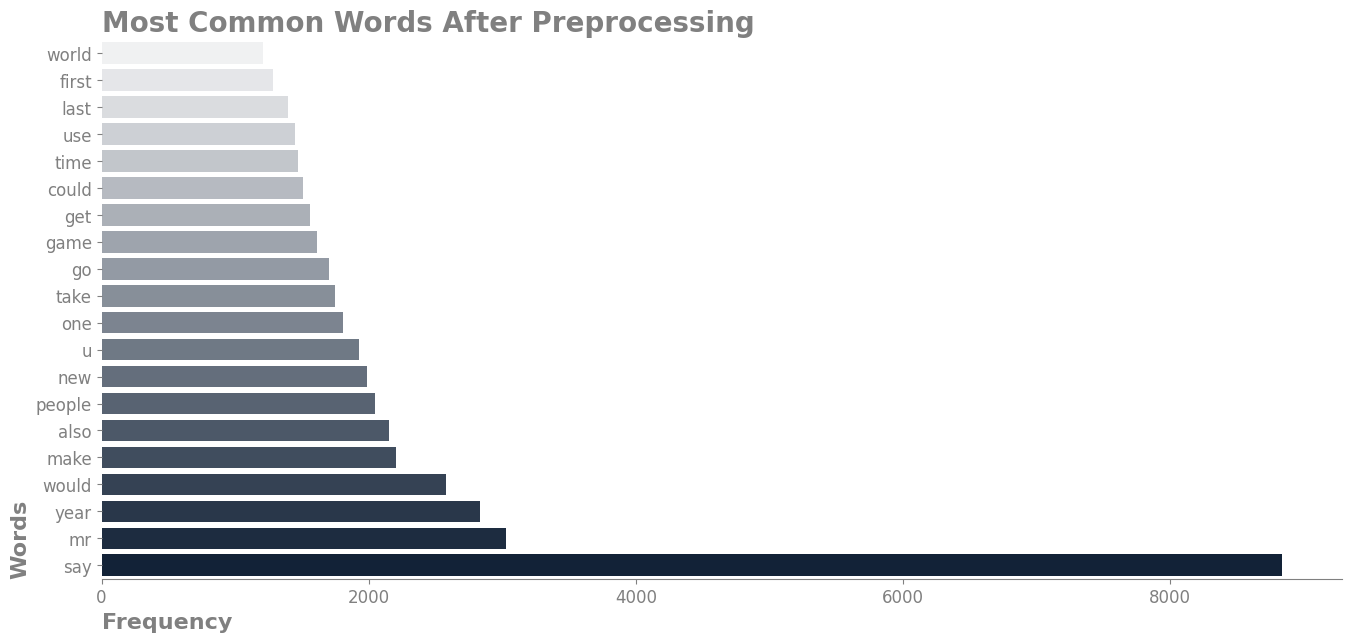

In [12]:
fig, ax = plt.subplots(figsize = (16,7))
sns.barplot(data=common_df.sort_values(by = "frequency",ascending=True), x = "frequency",y = "words",hue="words",palette="light:#0C213D")

ax.tick_params(axis="x",
               colors= "gray",
               labelsize= "large")
ax.tick_params(axis="y",
               colors= "gray",
               labelsize= "large")

ax.set_xlabel("Frequency",
              loc = "left",
              weight = "bold",
              color = "gray",
              fontsize = "16")

ax.set_ylabel("Words",
              loc="bottom",
              weight = "bold",
              color = "gray",
              fontsize = 16)
ax.set_title("Most Common Words After Preprocessing",
             loc= "left",
             weight = "bold",
             fontsize = 20,
             color = "gray")


ax.spines[["right","left","top"]].set_visible(False)
ax.spines[["bottom"]].set_color("gray")


### Text Vectorization Using TF-IDF

We use the TF-IDF (Term Frequency–Inverse Document Frequency) method to vectorize the preprocessed text data. 
This technique assigns a weight to each word that reflects its importance within the document. 
The output of this step is a sparse matrix, where each row represents a document and each column corresponds to a word feature.

In [18]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df["preprocessed_text"])
tfidf_matrix.shape

(2225, 27967)

### Displaying Top TF-IDF Features (First Document)

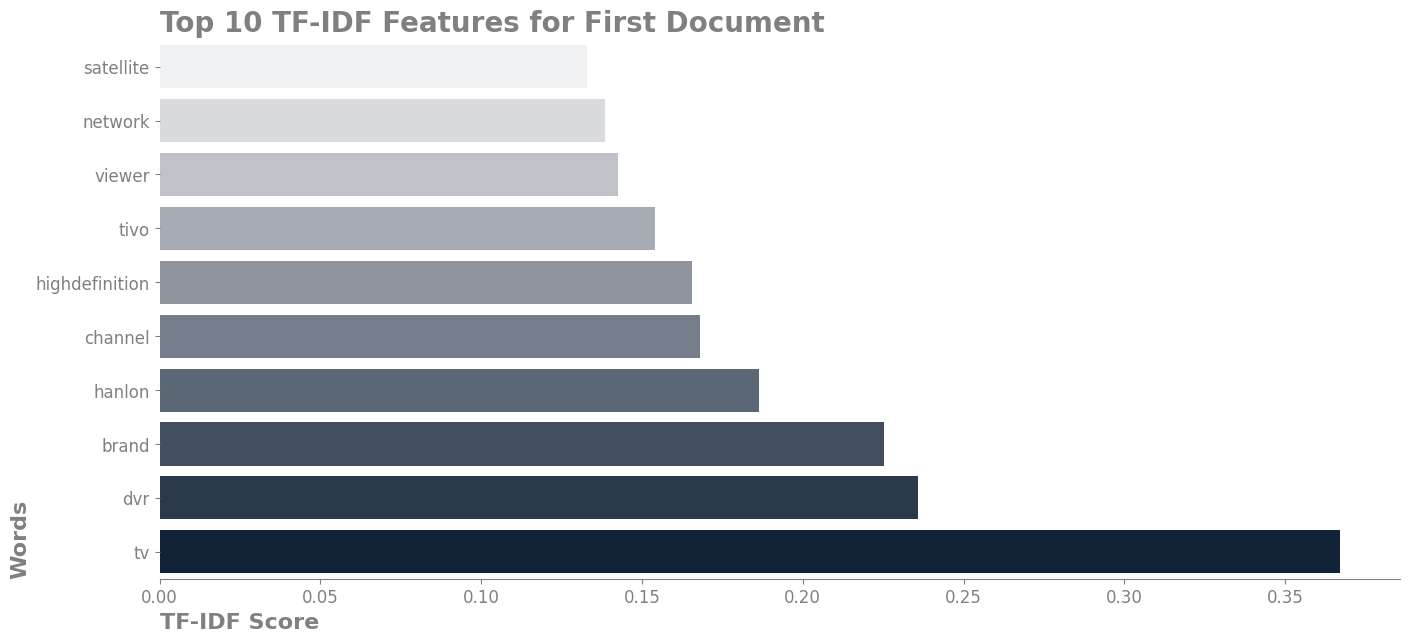

In [40]:
tfidf_sample = pd.DataFrame(tfidf_matrix[0].toarray().T, columns=["TF-IDF Score"])
tfidf_sample["Word"] = tfidf_vectorizer.get_feature_names_out()
tfidf_sample = tfidf_sample.sort_values(by="TF-IDF Score",ascending=False).head(10).sort_values(by = "TF-IDF Score")

fig , ax = plt.subplots(figsize = (16,7))
sns.barplot(data=tfidf_sample, x="TF-IDF Score", y="Word", hue= "Word", palette="light:#0C213D", ax=ax)

ax.tick_params(axis="x",
               colors= "gray",
               labelsize= "large")
ax.tick_params(axis="y",
               colors= "gray",
               labelsize= "large")

ax.set_xlabel("TF-IDF Score",
              loc = "left",
              weight = "bold",
              color = "gray",
              fontsize = "16")

ax.set_ylabel("Words",
              loc="bottom",
              weight = "bold",
              color = "gray",
              fontsize = 16)
ax.set_title("Top 10 TF-IDF Features for First Document",
             loc= "left",
             weight = "bold",
             fontsize = 20,
             color = "gray")


ax.spines[["right","left","top"]].set_visible(False)
ax.spines[["bottom"]].set_color("gray")


### Encoding Categories

In [44]:
label_encoder = LabelEncoder()

df["category_encoded"] = label_encoder.fit_transform(df["category"])
df[["category", "category_encoded"]].drop_duplicates()

,category,category_encoded
0,tech,4
1,business,0
2,sport,3
4,entertainment,1
5,politics,2


### Train Test Split

In [51]:
X = tfidf_matrix
y = df["category_encoded"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)
print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)

(1780, 27967) (1780,)
(445, 27967) (445,)
